In [1]:
# read csv file and print out the data
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from helper import transform_polars_df

import torch
# check if GPU is available
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
datapath = '../data/2010-2011 Solar home electricity data.csv'
# skip the first line in csv and read the next line as column
# then read the rest of the file and store as dataframe
df = pl.read_csv(datapath, skip_rows=1)
print(df)
print(df.columns)
episode_num = "episode_01"

shape: (269_735, 53)
┌──────────┬───────────┬──────────┬──────────────────────┬───┬───────┬───────┬───────┬───────┐
│ Customer ┆ Generator ┆ Postcode ┆ Consumption Category ┆ … ┆ 22:30 ┆ 23:00 ┆ 23:30 ┆ 0:00  │
│ ---      ┆ Capacity  ┆ ---      ┆ ---                  ┆   ┆ ---   ┆ ---   ┆ ---   ┆ ---   │
│ i64      ┆ ---       ┆ i64      ┆ str                  ┆   ┆ f64   ┆ f64   ┆ f64   ┆ f64   │
│          ┆ f64       ┆          ┆                      ┆   ┆       ┆       ┆       ┆       │
╞══════════╪═══════════╪══════════╪══════════════════════╪═══╪═══════╪═══════╪═══════╪═══════╡
│ 1        ┆ 3.78      ┆ 2076     ┆ GC                   ┆ … ┆ 0.378 ┆ 0.128 ┆ 0.078 ┆ 0.125 │
│ 1        ┆ 3.78      ┆ 2076     ┆ CL                   ┆ … ┆ 0.0   ┆ 0.0   ┆ 0.0   ┆ 1.075 │
│ 1        ┆ 3.78      ┆ 2076     ┆ GG                   ┆ … ┆ 0.0   ┆ 0.0   ┆ 0.0   ┆ 0.0   │
│ 1        ┆ 3.78      ┆ 2076     ┆ GC                   ┆ … ┆ 0.402 ┆ 0.142 ┆ 0.12  ┆ 0.111 │
│ 1        ┆ 3.78      ┆ 2076

In [ ]:
datapath = '../data/2011-2012 Solar home electricity data v2.csv'
# skip the first line in csv and read the next line as column
# then read the rest of the file and store as dataframe
df = pl.read_csv(datapath, skip_rows=1)
print(df)
print(df.columns)
episode_num = "episode_02"

In [ ]:
datapath = '../data/2012-2013 Solar home electricity data v2.csv'
# skip the first line in csv and read the next line as column
# then read the rest of the file and store as dataframe
df = pl.read_csv(datapath, skip_rows=1)
print(df)
print(df.columns)
episode_num = "episode_03"

In [3]:
# we can get the training and testing customers from the csv file
training_customers = np.loadtxt('../data/training_customers.csv', dtype=int)
testing_customers = np.loadtxt('../data/testing_customers.csv', dtype=int)

In [4]:
# alternatively, get all the unique customers as their own dataframes
customers = df['Customer'].unique()
# pick 80% of the random customers as training data
training_customers = np.random.choice(customers, int(0.8*len(customers)), replace=False)
# the rest of the customers are testing data
testing_customers = np.setdiff1d(customers, training_customers)

In [ ]:
# save the customers number to a csv file
np.savetxt('../data/training_customers.csv', training_customers, fmt='%s')
np.savetxt('../data/testing_customers.csv', testing_customers, fmt='%s')

In [4]:
# loop through each customer and use transform_polars_df to get the dataframe and store it in a list call dataset
training_dataset = []
for customer in training_customers:
    customer_df = df.filter(pl.col('Customer') == customer)
    try:
        newcustomerdf = transform_polars_df(customer_df, import_energy_price=0.23, export_energy_price=0.015, price_periods="7am – 10am | 4pm – 9pm", default_import_energy_price=0.15, default_export_energy_price=0.01)
    except Exception as e:
        print(f"Error with customer as training dataset: {customer}")
        print(e)
        break
    training_dataset.append(newcustomerdf)

testing_dataset = []
for customer in testing_customers:
    customer_df = df.filter(pl.col('Customer') == customer)
    try:
        newcustomerdf = transform_polars_df(customer_df, import_energy_price=0.23, export_energy_price=0.015, price_periods="7am – 10am | 4pm – 9pm", default_import_energy_price=0.15, default_export_energy_price=0.01)
    except Exception as e:
        print(f"Error with customer as testing dataset: {customer}")
        print(e)
        break
    testing_dataset.append(newcustomerdf)

In [5]:
import gymnasium as gym

from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
from stable_baselines3.common.env_checker import check_env
from EnergySimEnv import SolarBatteryEnv
from helper import make_env

testing_env_fns = [make_env(ds) for ds in testing_dataset]

num_step = None # pick the number of step for the simulation
test_envs = [env_fn(num_step) for env_fn in testing_env_fns]

/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [6]:
# Create a list of environment creation functions to build a vectorized environment.
training_env_fns = [make_env(ds) for ds in training_dataset]
training_vec_env = DummyVecEnv(training_env_fns)

num_total_steps = len(training_dataset[0])
print(f"Total number of steps possible in training dataset: {num_total_steps}")

train_envs = [env_fn(num_step) for env_fn in training_env_fns]

Total number of steps possible in training dataset: 17519


In [7]:
num_step = None # pick the number of step for the simulation/none for full length
#test_envs = [env_fn(num_step) for env_fn in testing_env_fns]
#train_envs = [env_fn(num_step) for env_fn in training_env_fns]
#combined_envs = test_envs + train_envs

In [8]:
# the below section trains a variety of models using stable baselines 3 RL
from stable_baselines3 import PPO, A2C, DDPG, SAC, TD3
from sb3train import train_model

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Training the model with the best hyperparameters...
training complete.


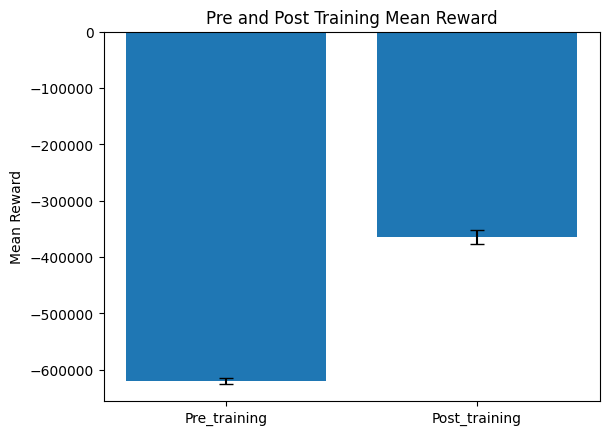

In [9]:
a2c_model, a2c_training_info = train_model(model_class=A2C, vec_env=training_vec_env, total_timesteps= num_total_steps, eval_env_fn=testing_env_fns[4], default_model=True)

In [10]:
a2c_model.save("../models/a2c_model.zip")

/usr/local/lib/python3.10/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Training the model with the best hyperparameters...
training complete.


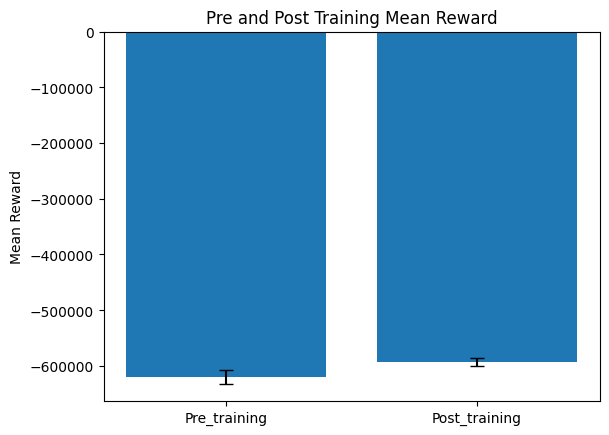

In [11]:
ppo_model, ppo_training_info = train_model(model_class=PPO, vec_env=training_vec_env, total_timesteps= num_total_steps, eval_env_fn=testing_env_fns[4], default_model=True)

In [12]:
ppo_model.save("../models/ppo_model.zip")

/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Training the model with the best hyperparameters...
training complete.


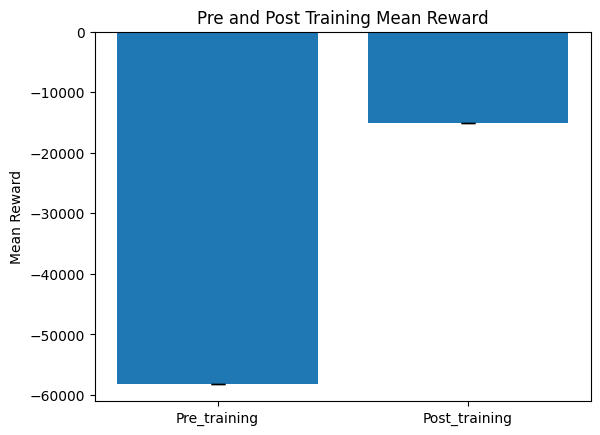

In [13]:
ddpg_model, ddpg_training_info = train_model(model_class=DDPG, vec_env=training_vec_env, total_timesteps= num_total_steps, eval_env_fn=testing_env_fns[4], default_model=True)

In [14]:
ddpg_model.save("../models/ddpg_model.zip")

/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Training the model with the best hyperparameters...
training complete.


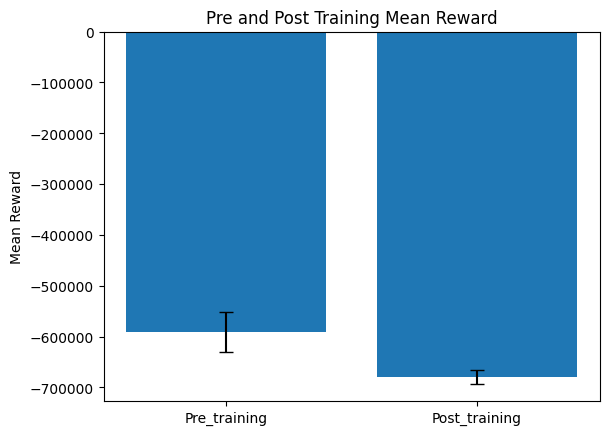

In [15]:
sac_model, sac_training_info = train_model(model_class=SAC, vec_env=training_vec_env, total_timesteps= num_total_steps, eval_env_fn=testing_env_fns[4], default_model=True)

In [16]:
sac_model.save("../models/sac_model.zip")   

/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Training the model with the best hyperparameters...
training complete.


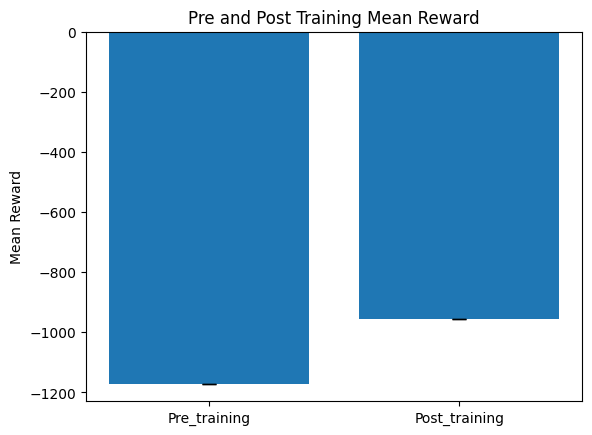

In [17]:
td3_model, td3_training_info = train_model(model_class=TD3, vec_env=training_vec_env, total_timesteps= num_total_steps, eval_env_fn=testing_env_fns[4], default_model=True)

In [18]:
td3_model.save('../models/td3_model.zip')